In [35]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Task 1.1: Perspective Correction
def order_points(pts):
    rect = np.zeros((4, 2), dtype='float32')
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left
    rect[2] = pts[np.argmax(s)]   # bottom-right
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)] # top-right
    rect[3] = pts[np.argmax(diff)] # bottom-left
    return rect

def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = max(int(widthA), int(widthB))
    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = max(int(heightA), int(heightB))
    dst = np.array([[0, 0], [maxWidth - 1, 0], [maxWidth - 1, maxHeight - 1], [0, maxHeight - 1]], dtype='float32')
    M = cv2.getPerspectiveTransform(rect, dst)
    return cv2.warpPerspective(image, M, (maxWidth, maxHeight))

# Task 1.2: Automatic Deskewing
def deskew(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.bitwise_not(gray)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    coords = np.column_stack(np.where(thresh > 0))
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return rotated, angle

In [36]:
from tensorflow import keras
from tensorflow.keras import layers

def build_cnn():
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Initialize and assume model is trained on MNIST as per previous steps
# model = build_cnn()
# model.fit(x_train, y_train...)

Found 20 images. Processing first 3 as samples...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step


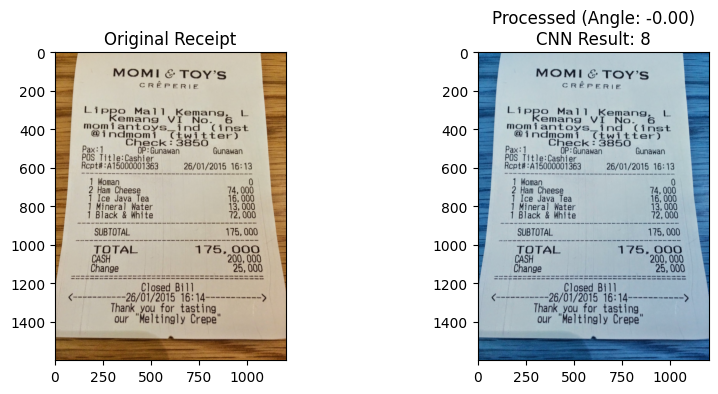

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


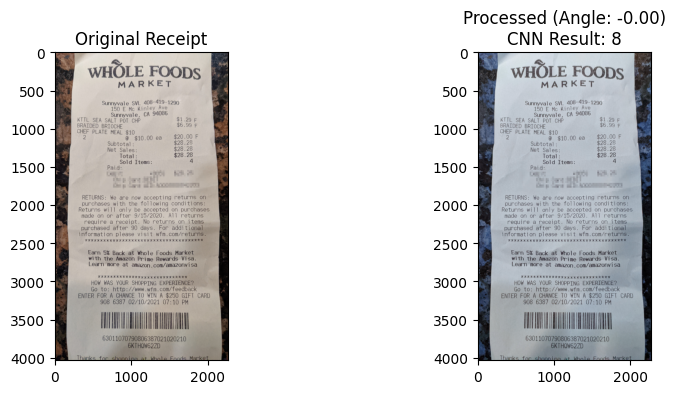

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


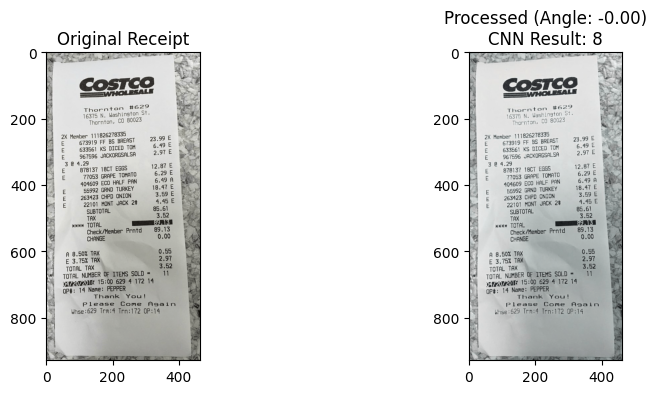

In [37]:
def run_ocr_on_dataset(dataset_path):
    # Supported image extensions
    valid_extensions = ('.jpg', '.jpeg', '.png')
    
    # Get list of images in the directory
    image_files = [f for f in os.listdir(dataset_path) if f.lower().endswith(valid_extensions)]
    
    if not image_files:
        print("No images found in the specified directory.")
        return

    print(f"Found {len(image_files)} images. Processing first 3 as samples...")

    for i in range(min(3, len(image_files))):
        img_path = os.path.join(dataset_path, image_files[i])
        img = cv2.imread(img_path)
        
        # 1. Advanced Preprocessing: Deskewing (Task 1.2)
        processed_img, angle = deskew(img)
        
        # 2. Morphological Operations: Closing to fix broken text (Task 1.3)
        kernel = np.ones((2,2), np.uint8)
        morph_img = cv2.morphologyEx(processed_img, cv2.MORPH_CLOSE, kernel)
        
        # 3. CNN Character Recognition (Part 2)
        gray = cv2.cvtColor(morph_img, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, (28, 28))
        normalized = resized.astype('float32') / 255
        final_input = normalized.reshape(1, 28, 28, 1)
        
        prediction = model.predict(final_input)
        result = np.argmax(prediction)
        
        # Displaying result
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original Receipt")
        
        plt.subplot(1, 2, 2)
        plt.imshow(morph_img, cmap='gray')
        plt.title(f"Processed (Angle: {angle:.2f})\nCNN Result: {result}")
        plt.show()

# EXECUTE ON YOUR DATASET
dataset_path = '/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/images'
run_ocr_on_dataset(dataset_path)